In [1]:
# 02_eda.ipynb - Детальний аналіз даних Yoochoose
# Мета: провести глибокий аналіз структури даних, виявити патерни та аномалії

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from src.config import DATA_DIR, FIGURES_DIR
from src.data_loader import load_clicks, load_buys

%matplotlib inline

# Налаштування візуалізації 
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Налаштовуємо seaborn
sns.set_theme(style="whitegrid")
sns.set_palette("husl")

# Створюємо папку для збереження графіків EDA
(FIGURES_DIR / 'eda').mkdir(parents=True, exist_ok=True)

print("Аналіз даних yoochoose")
print(f"Папка для графіків: {FIGURES_DIR / 'eda'}")

Аналіз даних yoochoose
Папка для графіків: d:\University\kursova\kursova\notebooks\..\figures\eda


In [4]:
print("Завантаження даних...")
clicks = load_clicks()
buys = load_buys()

# Основна статистика
n_sessions = clicks['Session_ID'].nunique()
n_items = clicks['Item_ID'].nunique()
n_categories = clicks['Category'].nunique()
n_buy_sessions = buys['Session_ID'].nunique() if len(buys) > 0 else 0

print(f"\n Загальна Статистика:")
print(f"   Clicks:          {len(clicks):,} записів")
print(f"   Buys:            {len(buys):,} записів")
print(f"   Унікальних сесій: {n_sessions:,}")
print(f"   Унікальних товарів: {n_items:,}")
print(f"   Унікальних категорій: {n_categories:,}")
print(f"   Сесій з покупками: {n_buy_sessions:,} ({n_buy_sessions/n_sessions*100:.2f}%)")

print(f"\n Пам'ятьЬ:")
print(f"   Clicks: {clicks.memory_usage(deep=True).sum() / 1024**2:.0f} MB")
print(f"   Buys:   {buys.memory_usage(deep=True).sum() / 1024**2:.0f} MB")

Завантаження даних...

 Загальна Статистика:
   Clicks:          33,003,944 записів
   Buys:            1,150,753 записів
   Унікальних сесій: 9,249,729
   Унікальних товарів: 52,739
   Унікальних категорій: 339
   Сесій з покупками: 509,696 (5.51%)

 Пам'ятьЬ:
   Clicks: 2582 MB
   Buys:   44 MB


In [5]:
print("Перевірка якості даних")

# Пропущені значення
missing_clicks = clicks.isnull().sum().sum()
missing_buys = buys.isnull().sum().sum() if len(buys) > 0 else 0

print(f"\n Пропущені значення:")
print(f"   Clicks: {missing_clicks} пропусків")
print(f"   Buys:   {missing_buys} пропусків")

# Дублікати
dup_clicks = clicks.duplicated().sum()
dup_buys = buys.duplicated().sum() if len(buys) > 0 else 0

print(f"\n Дублікати:")
print(f"   Clicks: {dup_clicks:,} дублікатів")
print(f"   Buys:   {dup_buys:,} дублікатів")

# Видаляємо дублікати
if dup_clicks > 0:
    clicks = clicks.drop_duplicates()
    print(f"\n Видалено {dup_clicks:,} дублікатів з clicks")
if dup_buys > 0:
    buys = buys.drop_duplicates()
    print(f" Видалено {dup_buys:,} дублікатів з buys")

print("\n Дані чисті, пропусків немає")

Перевірка якості даних

 Пропущені значення:
   Clicks: 0 пропусків
   Buys:   0 пропусків

 Дублікати:
   Clicks: 68 дублікатів
   Buys:   146 дублікатів

 Видалено 68 дублікатів з clicks
 Видалено 146 дублікатів з buys

 Дані чисті, пропусків немає


Аналіз довжини сесій

 Статистика довжини сесій:
   Середня:   3.57
   Медіана:   2
   Мінімум:   1
   Максимум:  200
   25-й перцентиль: 2
   75-й перцентиль: 4
   95-й перцентиль: 9
   99-й перцентиль: 18


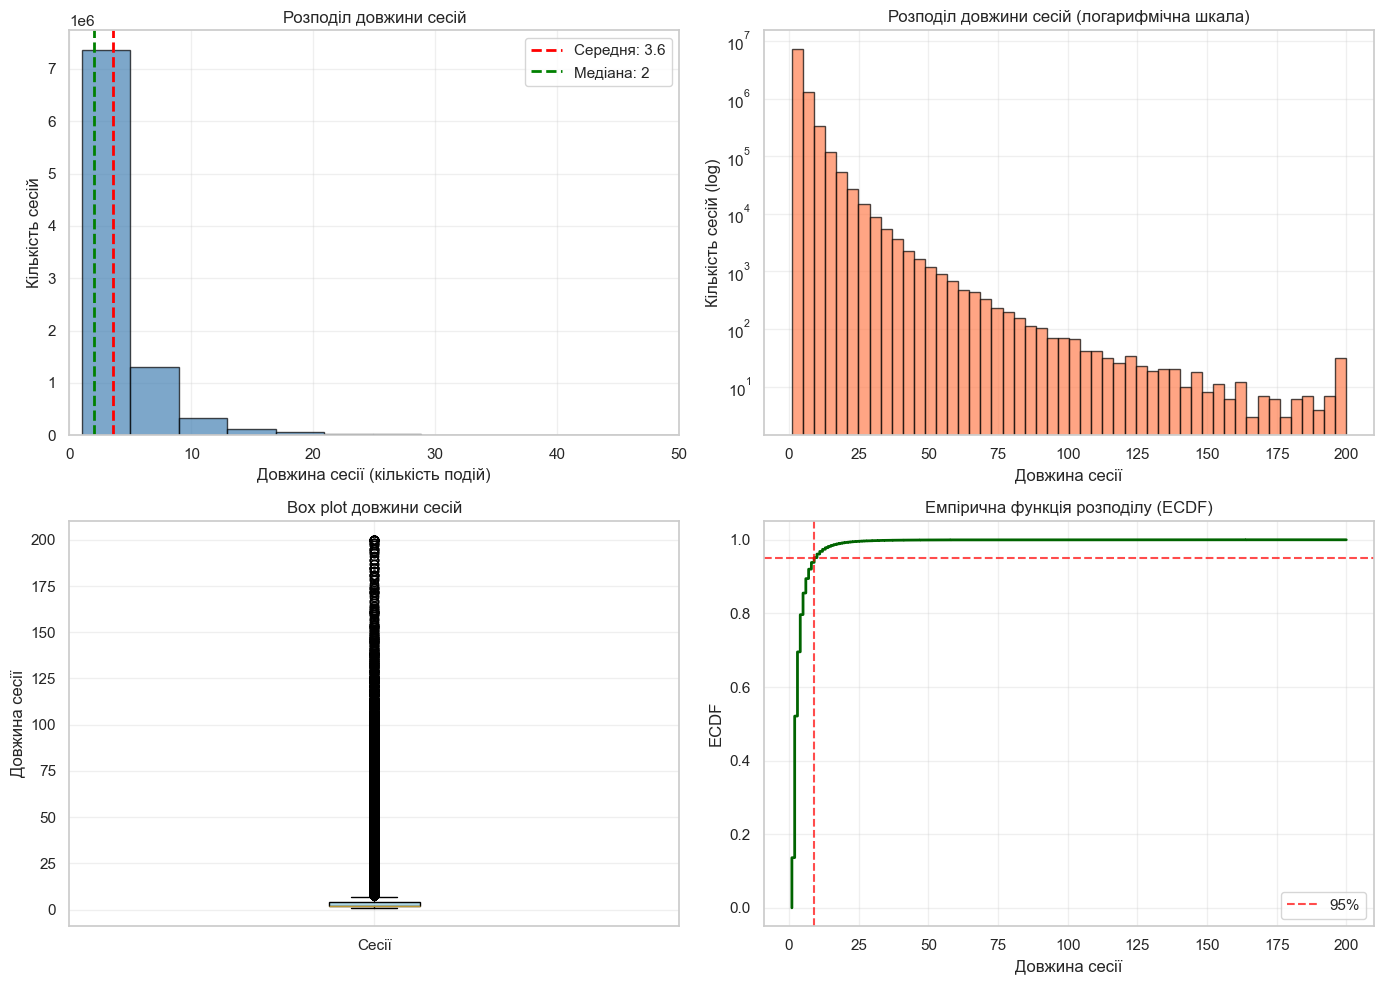


 Графік збережено: figures/eda/session_length_analysis.png


In [6]:
print("Аналіз довжини сесій")

# Розрахунок довжини сесій
session_lengths = clicks.groupby('Session_ID').size()

# Статистика
print(f"\n Статистика довжини сесій:")
print(f"   Середня:   {session_lengths.mean():.2f}")
print(f"   Медіана:   {session_lengths.median():.0f}")
print(f"   Мінімум:   {session_lengths.min()}")
print(f"   Максимум:  {session_lengths.max()}")
print(f"   25-й перцентиль: {session_lengths.quantile(0.25):.0f}")
print(f"   75-й перцентиль: {session_lengths.quantile(0.75):.0f}")
print(f"   95-й перцентиль: {session_lengths.quantile(0.95):.0f}")
print(f"   99-й перцентиль: {session_lengths.quantile(0.99):.0f}")

# Візуалізація
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гістограма
session_lengths.hist(bins=50, ax=axes[0,0], edgecolor='black', alpha=0.7, color='steelblue')
axes[0,0].axvline(session_lengths.mean(), color='red', linestyle='--', linewidth=2, label=f'Середня: {session_lengths.mean():.1f}')
axes[0,0].axvline(session_lengths.median(), color='green', linestyle='--', linewidth=2, label=f'Медіана: {session_lengths.median():.0f}')
axes[0,0].set_title('Розподіл довжини сесій')
axes[0,0].set_xlabel('Довжина сесії (кількість подій)')
axes[0,0].set_ylabel('Кількість сесій')
axes[0,0].legend()
axes[0,0].set_xlim(0, 50)

# Логарифмічна шкала
session_lengths.hist(bins=50, ax=axes[0,1], log=True, edgecolor='black', alpha=0.7, color='coral')
axes[0,1].set_title('Розподіл довжини сесій (логарифмічна шкала)')
axes[0,1].set_xlabel('Довжина сесії')
axes[0,1].set_ylabel('Кількість сесій (log)')

# Box plot
bp = axes[1,0].boxplot(session_lengths, vert=True, patch_artist=True, 
                        boxprops=dict(facecolor='lightblue'))
axes[1,0].set_title('Box plot довжини сесій')
axes[1,0].set_ylabel('Довжина сесії')
axes[1,0].set_xticklabels(['Сесії'])

# ECDF (емпірична функція розподілу)
sorted_lengths = np.sort(session_lengths)
ecdf = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths)
axes[1,1].plot(sorted_lengths, ecdf, linewidth=2, color='darkgreen')
axes[1,1].axhline(0.95, color='red', linestyle='--', alpha=0.7, label='95%')
axes[1,1].axvline(session_lengths.quantile(0.95), color='red', linestyle='--', alpha=0.7)
axes[1,1].set_title('Емпірична функція розподілу (ECDF)')
axes[1,1].set_xlabel('Довжина сесії')
axes[1,1].set_ylabel('ECDF')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda/session_length_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n Графік збережено: figures/eda/session_length_analysis.png")

Аналіз покупок

 Статистика конверсії:
   Всього сесій:           9,249,729
   Сесій з покупками:      509,696
   Сесій без покупок:      8,740,033
   Конверсія:              5.51%

 Довжина сесій:
   Середня довжина сесій з покупкою:  6.49
   Середня довжина сесій без покупки: 3.40


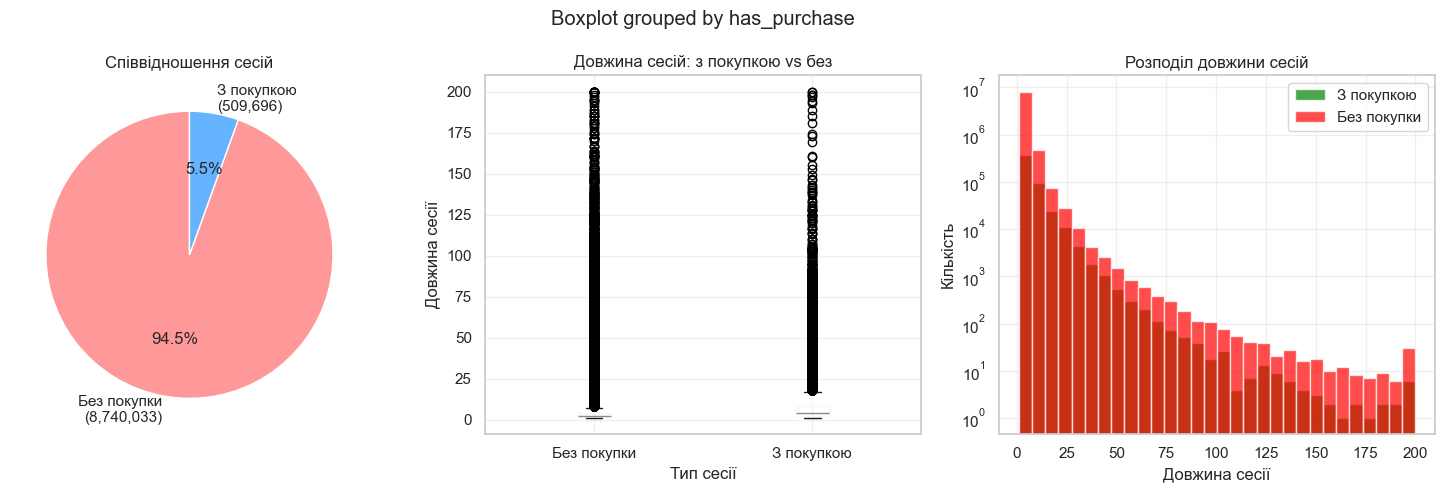


 Графік збережено: figures/eda/purchase_analysis.png


In [7]:
print("Аналіз покупок")

# Сесії з покупками
sessions_with_buys = buys['Session_ID'].unique() if len(buys) > 0 else []
clicks['has_purchase'] = clicks['Session_ID'].isin(sessions_with_buys)

# Статистика
n_sessions_total = clicks['Session_ID'].nunique()
n_sessions_with_buys = len(sessions_with_buys)
n_sessions_without_buys = n_sessions_total - n_sessions_with_buys
conversion_rate = n_sessions_with_buys / n_sessions_total * 100

print(f"\n Статистика конверсії:")
print(f"   Всього сесій:           {n_sessions_total:,}")
print(f"   Сесій з покупками:      {n_sessions_with_buys:,}")
print(f"   Сесій без покупок:      {n_sessions_without_buys:,}")
print(f"   Конверсія:              {conversion_rate:.2f}%")

# Довжина сесій для різних типів
session_stats = clicks.groupby('Session_ID').agg({
    'has_purchase': 'first',
    'Item_ID': 'count'
}).rename(columns={'Item_ID': 'length'})

print(f"\n Довжина сесій:")
print(f"   Середня довжина сесій з покупкою:  {session_stats[session_stats['has_purchase']]['length'].mean():.2f}")
print(f"   Середня довжина сесій без покупки: {session_stats[~session_stats['has_purchase']]['length'].mean():.2f}")

# Візуалізація
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pie chart
colors = ['#ff9999', '#66b3ff']
labels = [f'Без покупки\n({n_sessions_without_buys:,})', f'З покупкою\n({n_sessions_with_buys:,})']
axes[0].pie([n_sessions_without_buys, n_sessions_with_buys], labels=labels, 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Співвідношення сесій')

# Box plot
session_stats.boxplot(column='length', by='has_purchase', ax=axes[1])
axes[1].set_title('Довжина сесій: з покупкою vs без')
axes[1].set_xlabel('Тип сесії')
axes[1].set_ylabel('Довжина сесії')
axes[1].set_xticklabels(['Без покупки', 'З покупкою'])

# Гістограма
session_stats[session_stats['has_purchase']]['length'].hist(bins=30, alpha=0.7, label='З покупкою', color='green')
session_stats[~session_stats['has_purchase']]['length'].hist(bins=30, alpha=0.7, label='Без покупки', color='red')
axes[2].set_title('Розподіл довжини сесій')
axes[2].set_xlabel('Довжина сесії')
axes[2].set_ylabel('Кількість')
axes[2].legend()
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda/purchase_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n Графік збережено: figures/eda/purchase_analysis.png")

Часовий аналіз

 Часовий діапазон:
   Початок: 2014-04-01 03:00:00.124000+00:00
   Кінець:  2014-09-30 02:59:59.430000+00:00
   Тривалість: 181 days 23:59:59.306000

 Пікова активність:
   Година: 19:00 (2,562,232 подій)

 Піковий день:
   Неділя (7,360,071 подій)


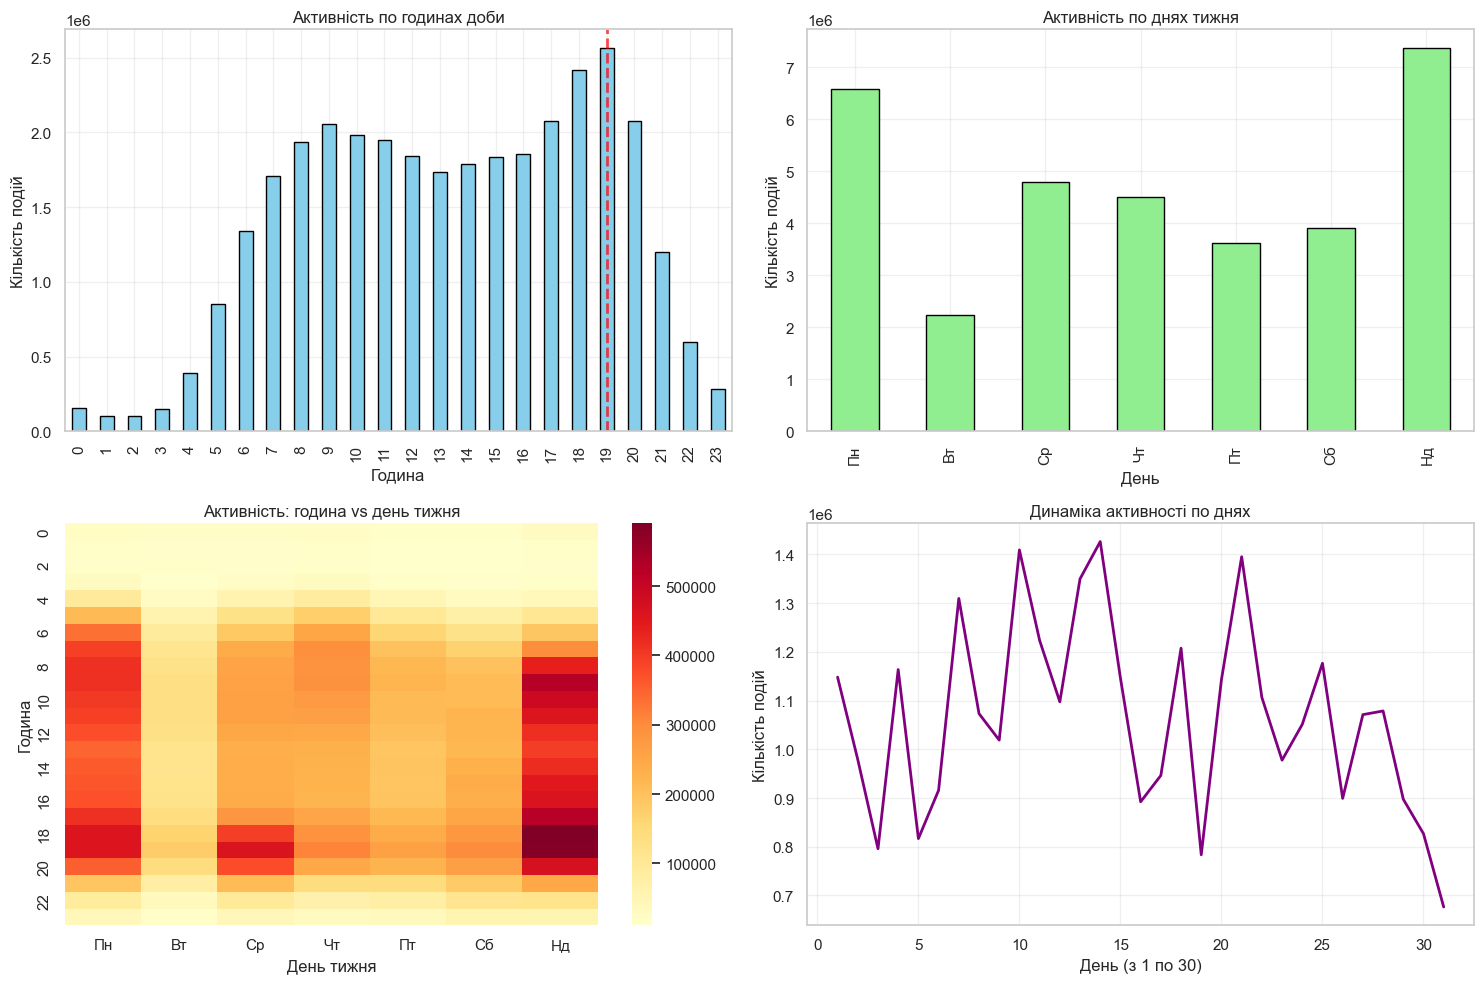


 Графік збережено: figures/eda/temporal_analysis.png


In [8]:
print("Часовий аналіз")

# Додаємо часові ознаки
clicks['hour'] = clicks['Timestamp'].dt.hour
clicks['dayofweek'] = clicks['Timestamp'].dt.dayofweek
clicks['month'] = clicks['Timestamp'].dt.month
clicks['day'] = clicks['Timestamp'].dt.day

# Часовий діапазон
print(f"\n Часовий діапазон:")
print(f"   Початок: {clicks['Timestamp'].min()}")
print(f"   Кінець:  {clicks['Timestamp'].max()}")
print(f"   Тривалість: {clicks['Timestamp'].max() - clicks['Timestamp'].min()}")

# Активність по годинах
hourly_activity = clicks.groupby('hour').size()
peak_hour = hourly_activity.idxmax()
print(f"\n Пікова активність:")
print(f"   Година: {peak_hour}:00 ({hourly_activity.max():,} подій)")

# Активність по днях
daily_activity = clicks.groupby('dayofweek').size()
peak_day = daily_activity.idxmax()
days_names = ['Понеділок', 'Вівторок', 'Середа', 'Четвер', "П'ятниця", 'Субота', 'Неділя']
print(f"\n Піковий день:")
print(f"   {days_names[peak_day]} ({daily_activity.max():,} подій)")

# Візуалізація
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# По годинах
hourly_activity.plot(kind='bar', ax=axes[0,0], color='skyblue', edgecolor='black')
axes[0,0].axvline(peak_hour, color='red', linestyle='--', linewidth=2, alpha=0.7)
axes[0,0].set_title('Активність по годинах доби')
axes[0,0].set_xlabel('Година')
axes[0,0].set_ylabel('Кількість подій')

# По днях тижня
daily_activity.index = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Нд']
daily_activity.plot(kind='bar', ax=axes[0,1], color='lightgreen', edgecolor='black')
axes[0,1].set_title('Активність по днях тижня')
axes[0,1].set_xlabel('День')
axes[0,1].set_ylabel('Кількість подій')

# Теплова карта: година vs день тижня
pivot_table = clicks.pivot_table(
    index='hour', 
    columns='dayofweek', 
    values='Session_ID', 
    aggfunc='count',
    fill_value=0
)
sns.heatmap(pivot_table, ax=axes[1,0], cmap='YlOrRd', annot=False, fmt='d')
axes[1,0].set_title('Активність: година vs день тижня')
axes[1,0].set_xlabel('День тижня')
axes[1,0].set_ylabel('Година')
axes[1,0].set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Нд'])

# Динаміка по днях
daily_trend = clicks.groupby('day').size()
daily_trend.plot(ax=axes[1,1], color='purple', linewidth=2)
axes[1,1].set_title('Динаміка активності по днях')
axes[1,1].set_xlabel('День (з 1 по 30)')
axes[1,1].set_ylabel('Кількість подій')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda/temporal_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n Графік збережено: figures/eda/temporal_analysis.png")

Аналіз товарів за категорією

 Топ-10 найпопулярніших товарів:
   1. Товар 643078800: 147,419 переглядів
   2. Товар 214853094: 125,690 переглядів
   3. Товар 214829878: 113,488 переглядів
   4. Товар 214853420: 78,448 переглядів
   5. Товар 214826610: 69,710 переглядів
   6. Товар 214853096: 66,067 переглядів
   7. Товар 214748336: 62,150 переглядів
   8. Товар 214834880: 61,668 переглядів
   9. Товар 214839973: 60,332 переглядів
   10. Товар 214821309: 55,854 переглядів

 Топ-10 найпопулярніших категорій:
   1. Категорія 0: 16,337,622 переглядів
   2. Категорія S: 10,769,579 переглядів
   3. Категорія 1: 1,671,754 переглядів
   4. Категорія 2: 1,292,246 переглядів
   5. Категорія 3: 789,713 переглядів
   6. Категорія 4: 480,569 переглядів
   7. Категорія 5: 471,922 переглядів
   8. Категорія 6: 414,696 переглядів
   9. Категорія 7: 389,910 переглядів
   10. Категорія 9: 105,282 переглядів


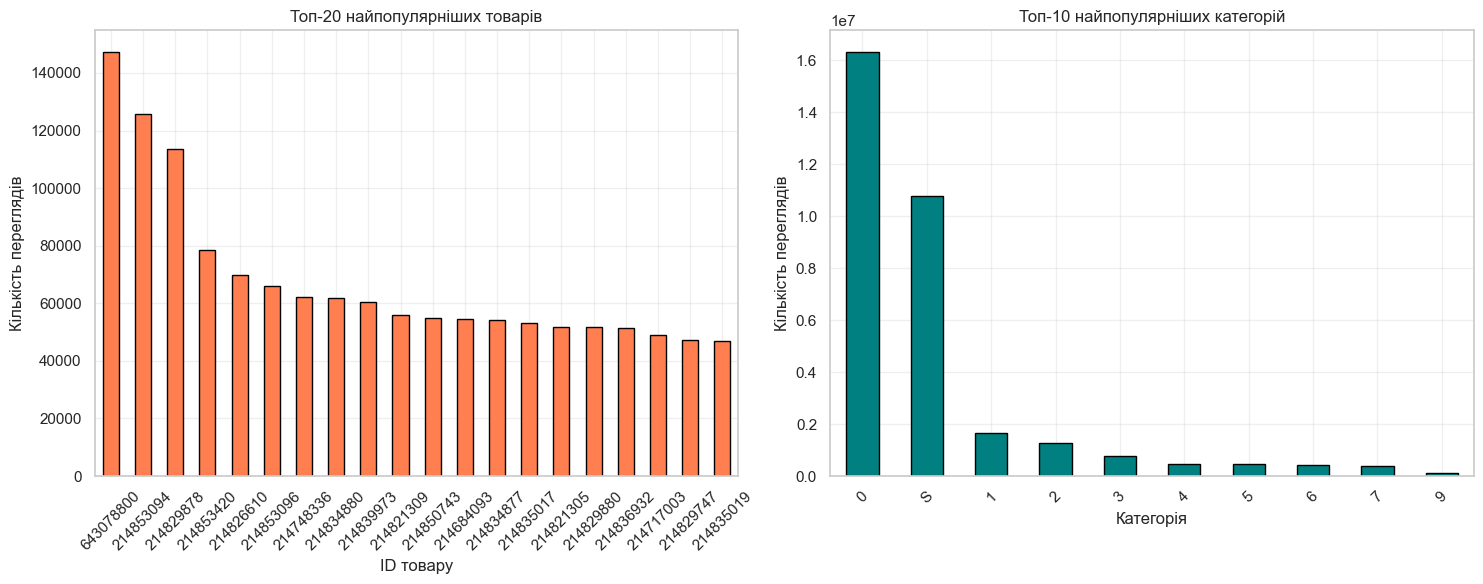


Графік збережено: figures/eda/top_items_categories.png


In [ ]:
print("Аналіз товарів за категорією")

# Топ товарів
top_items = clicks['Item_ID'].value_counts().head(20)

print(f"\n Топ-10 найпопулярніших товарів:")
for i, (item_id, count) in enumerate(top_items.head(10).items(), 1):
    print(f"   {i}. Товар {item_id}: {count:,} переглядів")

# Топ категорій
top_categories = clicks['Category'].value_counts().head(10)

print(f"\n Топ-10 найпопулярніших категорій:")
for i, (cat, count) in enumerate(top_categories.head(10).items(), 1):
    print(f"   {i}. Категорія {cat}: {count:,} переглядів")

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Топ товарів
top_items.plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Топ-20 найпопулярніших товарів')
axes[0].set_xlabel('ID товару')
axes[0].set_ylabel('Кількість переглядів')
axes[0].tick_params(axis='x', rotation=45)

# Топ категорій
top_categories.plot(kind='bar', ax=axes[1], color='teal', edgecolor='black')
axes[1].set_title('Топ-10 найпопулярніших категорій')
axes[1].set_xlabel('Категорія')
axes[1].set_ylabel('Кількість переглядів')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda/top_items_categories.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nГрафік збережено: figures/eda/top_items_categories.png")

Аналіз послідовностей

 Перші кліки в сесії:
   Середній час:        13.2:00
   Найчастіший час:    19:00

 Останні кліки в сесії:
   Середній час:        13.3:00
   Найчастіший час:    19:00


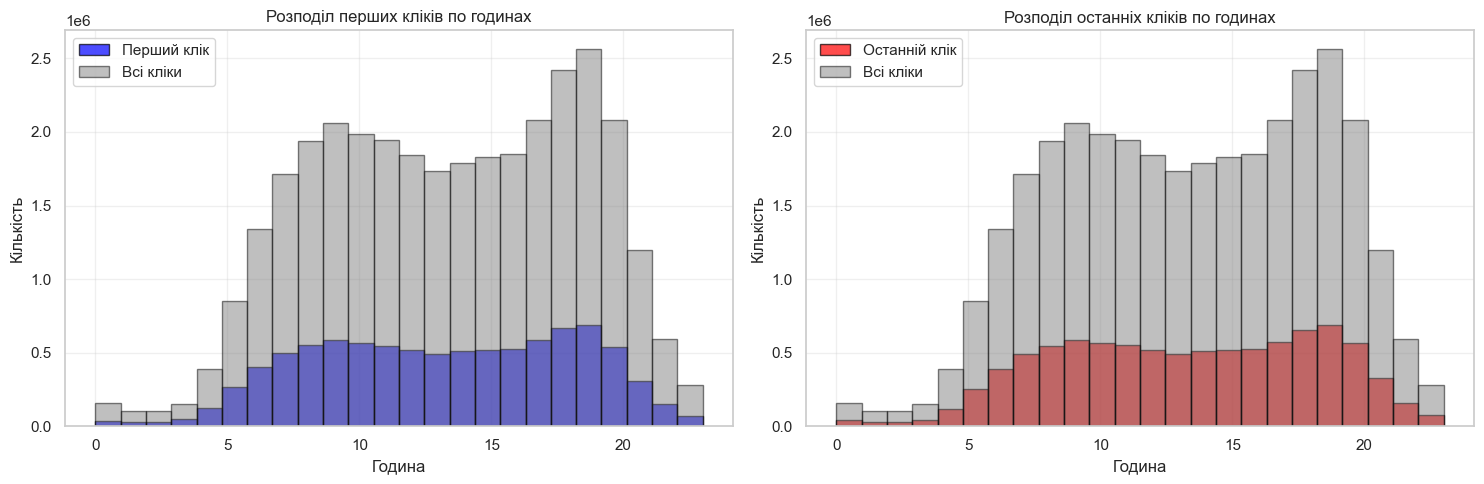


 Графік збережено: figures/eda/first_last_clicks.png


In [10]:
print("Аналіз послідовностей")

# Аналіз перших кліків
first_clicks = clicks.groupby('Session_ID').first().reset_index()
last_clicks = clicks.groupby('Session_ID').last().reset_index()

print(f"\n Перші кліки в сесії:")
print(f"   Середній час:        {first_clicks['hour'].mean():.1f}:00")
print(f"   Найчастіший час:    {first_clicks['hour'].mode()[0]}:00")

print(f"\n Останні кліки в сесії:")
print(f"   Середній час:        {last_clicks['hour'].mean():.1f}:00")
print(f"   Найчастіший час:    {last_clicks['hour'].mode()[0]}:00")

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Перші кліки
first_clicks['hour'].hist(bins=24, ax=axes[0], alpha=0.7, label='Перший клік', color='blue', edgecolor='black')
clicks['hour'].hist(bins=24, ax=axes[0], alpha=0.5, label='Всі кліки', color='gray', edgecolor='black')
axes[0].set_title('Розподіл перших кліків по годинах')
axes[0].set_xlabel('Година')
axes[0].set_ylabel('Кількість')
axes[0].legend()

# Останні кліки
last_clicks['hour'].hist(bins=24, ax=axes[1], alpha=0.7, label='Останній клік', color='red', edgecolor='black')
clicks['hour'].hist(bins=24, ax=axes[1], alpha=0.5, label='Всі кліки', color='gray', edgecolor='black')
axes[1].set_title('Розподіл останніх кліків по годинах')
axes[1].set_xlabel('Година')
axes[1].set_ylabel('Кількість')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda/first_last_clicks.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n Графік збережено: figures/eda/first_last_clicks.png")

In [12]:
print("АНАЛІЗ АНОМАЛІЙ")

q1 = session_lengths.quantile(0.25)
q3 = session_lengths.quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 3 * iqr

anomalous_sessions = session_lengths[session_lengths > upper_bound]

print(f"\n Аномальні сесії (за довжиною):")
print(f"   Кількість:      {len(anomalous_sessions):,}")
print(f"   Відсоток:       {len(anomalous_sessions)/len(session_lengths)*100:.2f}%")
print(f"   Поріг (> {upper_bound:.0f} подій)")

print(f"\n Обчислення тривалості сесій ")

#  обчислюємо тільки для сесій з >1 подією
sessions_with_multiple = clicks.groupby('Session_ID').filter(lambda x: len(x) > 1)

if len(sessions_with_multiple) > 0:
    # використовуємо agg з попередньо обчисленими значеннями
    session_times = sessions_with_multiple.groupby('Session_ID')['Timestamp'].agg(['min', 'max'])
    session_times['duration'] = (session_times['max'] - session_times['min']).dt.total_seconds() / 60
    
    # Аномалії за часом
    q1_dur = session_times['duration'].quantile(0.25)
    q3_dur = session_times['duration'].quantile(0.75)
    iqr_dur = q3_dur - q1_dur
    upper_bound_dur = q3_dur + 3 * iqr_dur
    
    anomalous_duration = session_times[session_times['duration'] > upper_bound_dur]
    
    print(f"\n Аномальні довгі сесії (за часом):")
    print(f"   Кількість:          {len(anomalous_duration):,}")
    print(f"   Відсоток:           {len(anomalous_duration)/len(session_times)*100:.2f}%")
    print(f"   Поріг (> {upper_bound_dur:.0f} хв)")
    print(f"   Середня тривалість: {anomalous_duration['duration'].mean():.1f} хв")
    print(f"   Максимальна:        {anomalous_duration['duration'].max():.1f} хв")
else:
    print("   Немає сесій з більш ніж однією подією")

АНАЛІЗ АНОМАЛІЙ

 Аномальні сесії (за довжиною):
   Кількість:      359,960
   Відсоток:       3.89%
   Поріг (> 10 подій)

 Обчислення тривалості сесій 

 Аномальні довгі сесії (за часом):
   Кількість:          495,436
   Відсоток:           6.20%
   Поріг (> 27 хв)
   Середня тривалість: 47.7 хв
   Максимальна:        4099.0 хв


In [13]:
print("Збереження результатів")


# Зберігаємо важливі метрики
eda_results = {
    'total_sessions': int(clicks['Session_ID'].nunique()),
    'total_clicks': int(len(clicks)),
    'total_buys': int(len(buys)),
    'avg_session_length': float(session_lengths.mean()),
    'median_session_length': float(session_lengths.median()),
    'max_session_length': int(session_lengths.max()),
    'p95_session_length': float(session_lengths.quantile(0.95)),
    'sessions_with_purchase': int(n_sessions_with_buys),
    'sessions_without_purchase': int(n_sessions_without_buys),
    'conversion_rate': float(conversion_rate),
    'peak_hour': int(peak_hour),
    'peak_day': str(days_names[peak_day]),
    'unique_items': int(clicks['Item_ID'].nunique()),
    'unique_categories': int(clicks['Category'].nunique()),
    'date_range_start': str(clicks['Timestamp'].min()),
    'date_range_end': str(clicks['Timestamp'].max()),
    'anomalous_sessions_count': int(len(anomalous_sessions)),
    'anomalous_sessions_percentage': float(len(anomalous_sessions)/len(session_lengths)*100)
}

import json
with open(DATA_DIR / 'eda_results.json', 'w', encoding='utf-8') as f:
    json.dump(eda_results, f, indent=4, ensure_ascii=False)

print("\n Результати EDA збережено:")
print(f"    {DATA_DIR / 'eda_results.json'}")
print(f"    {FIGURES_DIR / 'eda/'} (всі графіки)")

print("Підсумкова статистика EDA")

for key, value in eda_results.items():
    if isinstance(value, float):
        print(f"   {key}: {value:.2f}")
    else:
        print(f"   {key}: {value}")

Збереження результатів

 Результати EDA збережено:
    d:\University\kursova\kursova\notebooks\..\data\yoochoose\eda_results.json
    d:\University\kursova\kursova\notebooks\..\figures\eda (всі графіки)
Підсумкова статистика EDA
   total_sessions: 9249729
   total_clicks: 33003876
   total_buys: 1150607
   avg_session_length: 3.57
   median_session_length: 2.00
   max_session_length: 200
   p95_session_length: 9.00
   sessions_with_purchase: 509696
   sessions_without_purchase: 8740033
   conversion_rate: 5.51
   peak_hour: 19
   peak_day: Неділя
   unique_items: 52739
   unique_categories: 339
   date_range_start: 2014-04-01 03:00:00.124000+00:00
   date_range_end: 2014-09-30 02:59:59.430000+00:00
   anomalous_sessions_count: 359960
   anomalous_sessions_percentage: 3.89


In [14]:
print("Ключові висновки з EDA")

print(f"""

                   ВИСНОВКИ EDA                             

  1. РОЗПОДІЛ СЕСІЙ:                                         
     • Більшість сесій короткі (медіана {int(eda_results['median_session_length'])} подій)     
     • Є довгі "хвости" - сесії з багатьма подіями           
     • {round(eda_results['conversion_rate'], 1)}% сесій містять покупки                    
  2. ЧАСОВІ ПАТЕРНИ:                                          
     • Пікова активність: {eda_results['peak_hour']}:00                               
     • Найактивніший день: {eda_results['peak_day']}                                 
     • Чіткий добовий цикл активності                         

  3. ПОВЕДІНКА КОРИСТУВАЧІВ:                                  
     • Сесії з покупками в середньому довші                   
     • Перші кліки частіше в ранкові години                   
     • Останні кліки - ввечері                               

  4. АНОМАЛІЇ:                                               
     • {eda_results['anomalous_sessions_count']:,} сесій ({eda_results['anomalous_sessions_percentage']:.1f}%)   
     • аномально довгі (потребують аналізу)                  

  5. РЕКОМЕНДАЦІЇ ДЛЯ МОДЕЛІ:                                
     • Використовувати MAX_SEQUENCE_LENGTH = {int(eda_results['p95_session_length'])}                
     • Враховувати часові ознаки (година, день тижня)        
     • Балансувати класи (дисбаланс {eda_results['conversion_rate']:.1f}% / {100 - eda_results['conversion_rate']:.1f}%)    

""")


Ключові висновки з EDA


                   ВИСНОВКИ EDA                             

  1. РОЗПОДІЛ СЕСІЙ:                                         
     • Більшість сесій короткі (медіана 2 подій)     
     • Є довгі "хвости" - сесії з багатьма подіями           
     • 5.5% сесій містять покупки                    
  2. ЧАСОВІ ПАТЕРНИ:                                          
     • Пікова активність: 19:00                               
     • Найактивніший день: Неділя                                 
     • Чіткий добовий цикл активності                         

  3. ПОВЕДІНКА КОРИСТУВАЧІВ:                                  
     • Сесії з покупками в середньому довші                   
     • Перші кліки частіше в ранкові години                   
     • Останні кліки - ввечері                               

  4. АНОМАЛІЇ:                                               
     • 359,960 сесій (3.9%)   
     • аномально довгі (потребують аналізу)                  

  5. РЕКОМЕНДАЦІ